In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
import copy
import io
import os
import queue
import threading
from concurrent.futures import ThreadPoolExecutor
from datetime import date

import cma
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, root_mean_squared_error

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import (
    kge,
    kge_alpha,
    kge_beta,
    kge_r,
    mkge,
    mkge_alpha,
    nse,
)
from aquacrop_slovenia.parameter_defaults_jablje import (
    jablje_curve_number,
    jablje_groundwater,
    jablje_initial_cond,
    jablje_maize_params,
    jablje_optimal_management,
    jablje_readily_evaporable_water,
    jablje_soil_layers,
)
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison
from aquacrop_slovenia.reading_data import (
    get_co2_for_aquacrop,
    get_station_weather,
    get_yield,
    get_yield_for_comparison,
)

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "jablje"
MAX_WORKERS = os.cpu_count()

simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
    for year in range(1993, 2024)
    if year not in [2017]
]

temperatures, eto, rain = get_station_weather(8)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water,
)

observed_biomass = get_yield_for_comparison(LOCATION, "biomass", "A", "N3")
observed_grain = get_yield_for_comparison(LOCATION, "grain", "A", "N3")

INTEGER_PARAMS = {name for name, val in jablje_maize_params.items() if isinstance(val, int)}

In [4]:
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.RAMDISK_DIR / f"cmaes_jablje_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

print(f"Worker directories ready: {MAX_WORKERS}")

Worker directories ready: 28


In [5]:
# Parameter names, search bounds, and initial guess (midpoint of bounds)
param_names = [
    "harvest_index",
    "gdd_senescence",
    "gdd_flowering",
    "gdd_flowering_length",
    "max_canopy_cover",
    "cgc_gdd",
    "cdc_gdd",
    "ksat",
    "max_rooting_depth",
    "p_upper_senescence",
    "p_upper_stomata"
]

bounds = [
    (0.46, 0.56),   # harvest_index
    (1000, 1150),   # gdd_senescence
    (480,  530),    # gdd_flowering
    (130,  170),    # gdd_flowering_length
    (0.85, 0.95),   # max_canopy_cover
    (0.005, 0.02),  # cgc_gdd
    (0.005, 0.02),  # cdc_gdd
    (5, 1000),      # ksat
    (0.5, 2.5),     # max_rooting_depth
    (0.4, 0.7),     # p_upper_senescence
    (0.4, 0.7),     # p_upper_stomata
]

lower = np.array([b[0] for b in bounds])
upper = np.array([b[1] for b in bounds])
x0 = (lower + upper) / 2.0

print(f"Parameters: {param_names}")
print(f"x0:         {x0}")
print(f"Bounds:     {bounds}")

Parameters: ['harvest_index', 'gdd_senescence', 'gdd_flowering', 'gdd_flowering_length', 'max_canopy_cover', 'cgc_gdd', 'cdc_gdd', 'ksat', 'max_rooting_depth', 'p_upper_senescence', 'p_upper_stomata']
x0:         [5.100e-01 1.075e+03 5.050e+02 1.500e+02 9.000e-01 1.250e-02 1.250e-02
 5.025e+02 1.500e+00 5.500e-01 5.500e-01]
Bounds:     [(0.46, 0.56), (1000, 1150), (480, 530), (130, 170), (0.85, 0.95), (0.005, 0.02), (0.005, 0.02), (5, 1000), (0.5, 2.5), (0.4, 0.7), (0.4, 0.7)]


In [6]:
def evaluate_params(param_values):
    """Run one candidate and return all metrics for both grain and biomass."""
    working_dir = dir_queue.get()
    try:
        crop_params = copy.deepcopy(jablje_maize_params)
        current_ksat = None

        for name, val in zip(param_names, param_values):
            if name == "ksat":
                current_ksat = float(val)
            else:
                crop_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

        crop = Crop(
            name=f"{LOCATION} maize",
            description="cma-es",
            params=crop_params,
        )

        if current_ksat is not None:
            modified_layers = copy.deepcopy(jablje_soil_layers)
            for layer in modified_layers:
                layer.ksat = current_ksat
            current_soil = Soil(
                name=f"{LOCATION} soil",
                description=f"{LOCATION} loamy sand soil",
                soil_layers=modified_layers,
                curve_number=jablje_curve_number,
                readily_evaporable_water=jablje_readily_evaporable_water,
            )
        else:
            current_soil = soil

        simulation = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=current_soil,
            management=jablje_optimal_management,
            initial_conditions=jablje_initial_cond,
            climate=weather,
            #ground_water=jablje_groundwater,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )

        nan_metrics = {
            f"{prefix}_{s}": np.nan
            for prefix in ("biomass", "grain")
            for s in ["rmse", "r2", "nse", "kge", "mkge", "kge_r", "kge_beta", "kge_alpha", "mkge_alpha"]
        }

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                results = simulation.run()
        except Exception:
            return nan_metrics

        seasonal = results["season"][["Year1", "BioMass", "Y(dry)"]].rename(
            columns={"Year1": "year", "BioMass": "biomass_modeled", "Y(dry)": "grain_modeled"}
        )

        def compute_metrics(observed_df, modeled_col, prefix):
            merged = observed_df.merge(seasonal[["year", modeled_col]], on="year")
            y_obs = merged["yield"].values
            y_mod = merged[modeled_col].values
            return {
                f"{prefix}_rmse":       root_mean_squared_error(y_obs, y_mod),
                f"{prefix}_nse":        nse(y_mod, y_obs),
                f"{prefix}_kge":        kge(y_mod, y_obs),
                f"{prefix}_mkge":       mkge(y_mod, y_obs),
                f"{prefix}_kge_r":      kge_r(y_mod, y_obs),
                f"{prefix}_kge_beta":   kge_beta(y_mod, y_obs),
                f"{prefix}_kge_alpha":  kge_alpha(y_mod, y_obs),
                f"{prefix}_mkge_alpha": mkge_alpha(y_mod, y_obs),
            }

        return {
            **compute_metrics(observed_biomass, "biomass_modeled", "biomass"),
            **compute_metrics(observed_grain,   "grain_modeled",   "grain"),
        }
    finally:
        dir_queue.put(working_dir)

In [7]:
eval_log = []           # collects every evaluated candidate for post-analysis
eval_log_lock = threading.Lock()
convergence_logs = {}   # objective_name -> [(iteration, fbest), ...]

mean_biomass = observed_biomass["yield"].mean()
mean_grain   = observed_grain["yield"].mean()
print(f"Mean observed biomass: {mean_biomass:.1f}  |  mean observed grain: {mean_grain:.1f}")


def make_objective(scalar_fn):
    """Return a function that evaluates one candidate, logs it, and returns a scalar."""
    def objective(param_values):
        r = evaluate_params(param_values)
        with eval_log_lock:
            eval_log.append({**dict(zip(param_names, param_values)), **r})
        return scalar_fn(r)
    return objective


objectives = {
    "biomass_rmse":   make_objective(lambda r: r["biomass_rmse"]),
    "biomass_mkge":   make_objective(lambda r: -r["biomass_mkge"]),   # negate: CMA-ES minimises
    "grain_rmse":     make_objective(lambda r: r["grain_rmse"]),
    "grain_mkge":     make_objective(lambda r: -r["grain_mkge"]),     # negate: CMA-ES minimises
    "combined_nrmse": make_objective(
        lambda r: r["biomass_rmse"] / mean_biomass + r["grain_rmse"] / mean_grain
    ),
}

Mean observed biomass: 18.3  |  mean observed grain: 9.4


In [8]:
# CMA-ES settings
SIGMA0 = 0.01

# Set popsize >= MAX_WORKERS so every core gets work each generation.
# The default (4 + floor(3*ln(n)) ≈ 9 for n=6) is often smaller than core count.
default_popsize = 4 + int(3 * np.log(len(param_names)))
POPSIZE = max(MAX_WORKERS, default_popsize)

CMAES_OPTIONS = {
    "bounds": [lower.tolist(), upper.tolist()],
    "popsize": POPSIZE,
    "maxiter": 100,
    "tolx": 1e-5,
    "tolfun": 1e-5,
    "seed": 10,
    "verbose": 3,
}

print(f"Cores: {MAX_WORKERS}  |  default popsize: {default_popsize}  |  using popsize: {POPSIZE}")
print(f"Options: {CMAES_OPTIONS}")

Cores: 28  |  default popsize: 11  |  using popsize: 28
Options: {'bounds': [[0.46, 1000.0, 480.0, 130.0, 0.85, 0.005, 0.005, 5.0, 0.5, 0.4, 0.4], [0.56, 1150.0, 530.0, 170.0, 0.95, 0.02, 0.02, 1000.0, 2.5, 0.7, 0.7]], 'popsize': 28, 'maxiter': 100, 'tolx': 1e-05, 'tolfun': 1e-05, 'seed': 10, 'verbose': 3}


In [9]:
def parallel_evaluate(objective_fn, solutions):
    """Evaluate a list of candidate solutions in parallel using ThreadPoolExecutor."""
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        return list(executor.map(objective_fn, solutions))

In [10]:
def run_cmaes(objective_name):
    """Run CMA-ES for a given objective and return the CMAEvolutionStrategy object."""
    objective_fn = objectives[objective_name]
    es = cma.CMAEvolutionStrategy(x0, SIGMA0, CMAES_OPTIONS)
    convergence_logs[objective_name] = []

    while not es.stop():
        solutions = es.ask()
        fitnesses = parallel_evaluate(objective_fn, solutions)
        penalty = max((f for f in fitnesses if np.isfinite(f)), default=1e6) * 10
        fitnesses = [penalty if not np.isfinite(f) else f for f in fitnesses]
        es.tell(solutions, fitnesses)
        es.disp()
        convergence_logs[objective_name].append((es.result.iterations, es.result.fbest))

    es.result_pretty()
    return es

In [48]:
eval_log.clear()
print("=== Optimising for BIOMASS RMSE ===")
es_biomass = run_cmaes("biomass_rmse")
print(f"\nBest biomass RMSE: {es_biomass.result.fbest:.4f}")
print("Best parameters:")
for name, val in zip(param_names, es_biomass.result.xbest):
    print(f"  {name}: {val:.4f}")

C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\cma\evolution_strategy.py:1541: UserWarning: Sampling standard deviation i=0 (and 3 others) at iteration 0 multiplied by 0.11111111111111113 to stds[0]=0.03333333333333334
  warnings.warn("Sampling standard deviation i={0}{4} at iteration {1}"


In [39]:
eval_log.clear()
print("=== Optimising for BIOMASS mKGE ===")
es_biomass_mkge = run_cmaes("biomass_mkge")
print(f"\nBest biomass mKGE: {-es_biomass_mkge.result.fbest:.4f}")
print("Best parameters:")
for name, val in zip(param_names, es_biomass_mkge.result.xbest):
    print(f"  {name}: {val:.4f}")

C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\cma\evolution_strategy.py:1541: UserWarning: Sampling standard deviation i=0 (and 3 others) at iteration 0 multiplied by 0.11111111111111113 to stds[0]=0.03333333333333334
  warnings.warn("Sampling standard deviation i={0}{4} at iteration {1}"


In [18]:
eval_log.clear()
print("=== Optimising for GRAIN RMSE ===")
es_grain = run_cmaes("grain_rmse")
print(f"\nBest grain RMSE: {es_grain.result.fbest:.4f}")
print("Best parameters:")
for name, val in zip(param_names, es_grain.result.xbest):
    print(f"  {name}: {val:.4f}")

C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\cma\evolution_strategy.py:1541: UserWarning: Sampling standard deviation i=0 (and 3 others) at iteration 0 multiplied by 0.11111111111111113 to stds[0]=0.03333333333333334
  warnings.warn("Sampling standard deviation i={0}{4} at iteration {1}"


In [11]:
eval_log.clear()
print("=== Optimising for GRAIN mKGE ===")
es_grain_mkge = run_cmaes("grain_mkge")
print(f"\nBest grain mKGE: {-es_grain_mkge.result.fbest:.4f}")
print("Best parameters:")
for name, val in zip(param_names, es_grain_mkge.result.xbest):
    print(f"  {name}: {val:.4f}")

=== Optimising for GRAIN mKGE ===
(14_w,28)-aCMA-ES (mu_w=8.1,w_1=21%) in dimension 11 (seed=10, Mon Jun 29 15:12:55 2026)


C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\cma\evolution_strategy.py:1541: UserWarning: Sampling standard deviation i=5 (and 1 others) at iteration 0 multiplied by 0.49998863649276754 to stds[5]=0.004999999999999999
  warnings.warn("Sampling standard deviation i={0}{4} at iteration {1}"


Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     28 -1.713107670130831e-02 1.0e+00 9.98e-03  5e-03  1e-02 0:06.4
AquaCrop simulation completed successfully
Parsing simulation results...
AquaCrop simulation completed successfully
Parsing simulation results...
AquaCrop simulation completed successfully
Parsing simulation results...
AquaCrop simulation completed successfully
Parsing simulation results...
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [19]:
eval_log.clear()
print("=== Optimising for COMBINED normalised RMSE (biomass + grain) ===")
es_combined = run_cmaes("combined_nrmse")
print(f"\nBest combined nRMSE: {es_combined.result.fbest:.6f}")
print("Best parameters:")
for name, val in zip(param_names, es_combined.result.xbest):
    print(f"  {name}: {val:.4f}")

C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\cma\evolution_strategy.py:1541: UserWarning: Sampling standard deviation i=0 (and 3 others) at iteration 0 multiplied by 0.11111111111111113 to stds[0]=0.03333333333333334
  warnings.warn("Sampling standard deviation i={0}{4} at iteration {1}"


In [13]:
# Re-evaluate each best solution to get the full metric set
cmaes_runs = {
    #"biomass_rmse":   es_biomass.result.xbest,
    #"biomass_mkge":   es_biomass_mkge.result.xbest,
    #"grain_rmse":     es_grain.result.xbest,
    "grain_mkge":     es_grain_mkge.result.xbest,
    #"combined_nrmse": es_combined.result.xbest,
}

summary_rows = []
for run_name, x in cmaes_runs.items():
    metrics = evaluate_params(x)
    row = {"optimised_for": run_name, **dict(zip(param_names, x)), **metrics}
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("optimised_for")
summary_df

,harvest_index,gdd_senescence,gdd_flowering,gdd_flowering_length,max_canopy_cover,cgc_gdd,cdc_gdd,ksat,max_rooting_depth,p_upper_senescence,...,biomass_kge_alpha,biomass_mkge_alpha,grain_rmse,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
optimised_for,,,,,,,,,,,,,,,,,,,,,
grain_mkge,0.557381,1076.477359,504.979376,149.759473,0.948855,0.013201,0.015631,502.364045,0.501473,0.68588,...,0.790593,0.82791,2.006161,0.044149,0.512462,0.526625,0.536359,0.921063,0.871548,0.946242


In [14]:
display_cols = [
    "biomass_rmse", "biomass_nse", "biomass_kge", "biomass_mkge",
    "grain_rmse", "grain_nse",   "grain_kge",   "grain_mkge",
]
print("Metric comparison across optimisation targets:")
summary_df[display_cols].round(4)

,biomass_rmse,biomass_nse,biomass_kge,biomass_mkge,grain_rmse,grain_nse,grain_kge,grain_mkge
optimised_for,,,,,,,,
grain_mkge,4.5733,-0.1094,0.3145,0.325,2.0062,0.0441,0.5125,0.5266


In [15]:
# Convergence info from each run
for name, es in [
    #("biomass_rmse",   es_biomass),
    #("biomass_mkge",   es_biomass_mkge),
    #("grain_rmse",     es_grain),
    ("grain_mkge",     es_grain_mkge),
    #("combined_nrmse", es_combined),
]:
    r = es.result
    print(f"{name}: evaluations={r.evaluations}, iterations={r.iterations}, stop={es.stop()}")

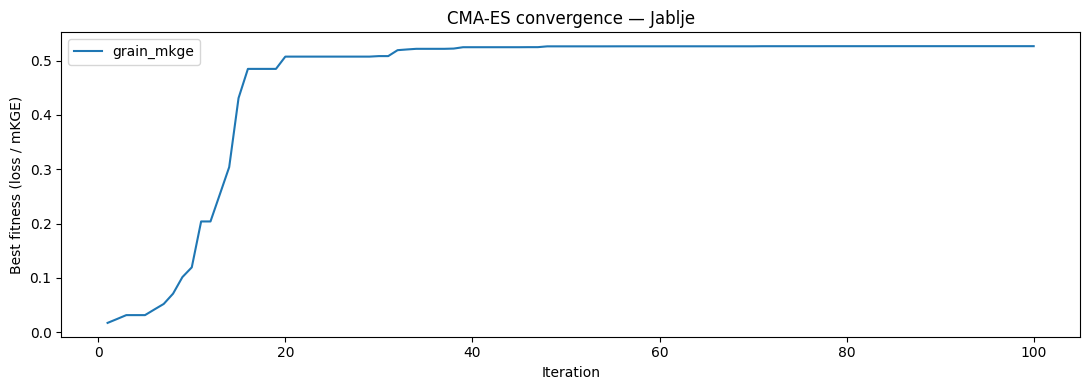

In [16]:
import matplotlib.pyplot as plt

# Objectives whose fitness is already a loss (lower = better) — no sign flip needed
loss_objectives = {"biomass_rmse", "grain_rmse", "combined_nrmse"}

fig, ax = plt.subplots(figsize=(11, 4))

for obj_name, log in convergence_logs.items():
    iters, fbest = zip(*log)
    values = [f if obj_name in loss_objectives else -f for f in fbest]
    ax.plot(iters, values, label=obj_name)

ax.set_xlabel("Iteration")
ax.set_ylabel("Best fitness (loss / mKGE)")
ax.set_title("CMA-ES convergence — Jablje")
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# All evaluated candidates from the last CMA-ES run (combined)
all_evals_df = pd.DataFrame(eval_log)
print(f"Total evaluations stored from last run: {len(all_evals_df)}")
all_evals_df.sort_values("grain_mkge")

,harvest_index,gdd_senescence,gdd_flowering,gdd_flowering_length,max_canopy_cover,cgc_gdd,cdc_gdd,ksat,max_rooting_depth,p_upper_senescence,...,biomass_kge_alpha,biomass_mkge_alpha,grain_rmse,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
12,0.507658,1075.000573,504.992929,150.005467,0.908981,0.005000,0.017354,502.499435,1.504609,0.556624,...,0.025697,0.220163,8.688823,-16.930016,-0.490787,-0.338627,0.310734,0.102782,0.029249,0.284575
580,0.506154,1075.204207,505.253775,150.110852,0.949801,0.016307,0.018545,502.325163,0.515318,0.400484,...,1.407954,1.578928,3.843994,-2.509330,0.126407,-0.313975,0.441955,0.750850,1.624240,2.163202
571,0.514186,1075.559819,505.183055,149.802475,0.942596,0.018912,0.019500,502.644640,0.500181,0.410081,...,1.433076,1.551883,3.804846,-2.438215,0.086662,-0.308664,0.421299,0.776033,1.670171,2.152191
2,0.516013,1074.989549,504.992020,150.019851,0.915926,0.006090,0.011427,502.499342,1.478682,0.549512,...,0.046865,0.234533,7.985464,-14.144645,-0.427748,-0.277916,0.314488,0.179425,0.053853,0.300143
22,0.498756,1074.996669,504.992086,150.002742,0.894983,0.006384,0.015249,502.511002,1.505644,0.542872,...,0.054749,0.237197,7.803933,-13.463915,-0.413020,-0.264539,0.312423,0.199276,0.060477,0.303482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2796,0.556812,1076.428540,505.055007,149.727030,0.947407,0.013203,0.015605,502.373051,0.500498,0.690744,...,0.790266,0.827441,2.005417,0.044857,0.512428,0.526622,0.536389,0.921197,0.871234,0.945762
2566,0.558191,1076.444972,505.087880,149.729840,0.947908,0.013201,0.015492,502.286077,0.503135,0.688753,...,0.788476,0.825472,2.003413,0.046765,0.512186,0.526624,0.536617,0.921293,0.869448,0.943726
2591,0.556686,1076.480652,505.097515,149.760513,0.947252,0.013201,0.015493,502.336401,0.504093,0.686860,...,0.788503,0.825504,2.003413,0.046765,0.512186,0.526624,0.536617,0.921293,0.869448,0.943726
2660,0.557593,1076.362906,505.004448,149.764845,0.949007,0.013203,0.015479,502.304964,0.500029,0.690245,...,0.788323,0.825204,2.002890,0.047263,0.512181,0.526624,0.536630,0.921410,0.869314,0.943461


In [18]:
es_grain_mkge.result.xbest

array([5.57381033e-01, 1.07647736e+03, 5.04979376e+02, 1.49759473e+02,
       9.48855408e-01, 1.32014587e-02, 1.56309741e-02, 5.02364045e+02,
       5.01472822e-01, 6.85880297e-01, 4.00004699e-01])

In [19]:
bounds

[(0.46, 0.56),
 (1000, 1150),
 (480, 530),
 (130, 170),
 (0.85, 0.95),
 (0.005, 0.02),
 (0.005, 0.02),
 (5, 1000),
 (0.5, 2.5),
 (0.4, 0.7),
 (0.4, 0.7)]

In [20]:
output_path = config.RESULTS_DIR / "cmaes_jablje_summary2.pkl"
summary_df.reset_index().to_pickle(output_path)
print(f"Saved summary ({len(summary_df)} rows) to {output_path}")

In [21]:
def rerun_best(param_values, label):
    """Re-run a full simulation with given params and return seasonal results."""
    params = copy.deepcopy(jablje_maize_params)
    current_ksat = None
    for name, val in zip(param_names, param_values):
        if name == "ksat":
            current_ksat = float(val)
        else:
            params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

    if current_ksat is not None:
        modified_layers = copy.deepcopy(jablje_soil_layers)
        for layer in modified_layers:
            layer.ksat = current_ksat
        current_soil = Soil(
            name=f"{LOCATION} soil",
            description=f"{LOCATION} loamy sand soil",
            soil_layers=modified_layers,
            curve_number=jablje_curve_number,
            readily_evaporable_water=jablje_readily_evaporable_water,
        )
    else:
        current_soil = soil

    best_dir = config.RAMDISK_DIR / f"cmaes_jablje_best_{label}"
    best_dir.mkdir(parents=True, exist_ok=True)

    sim = AquaCrop(
        simulation_periods=simulation_periods,
        crop=Crop(name=f"{LOCATION} maize ({label})", description=label, params=params),
        soil=current_soil,
        management=jablje_optimal_management,
        initial_conditions=jablje_initial_cond,
        climate=weather,
        #ground_water=jablje_groundwater,
        working_dir=best_dir,
        need_daily_output=False,
        need_seasonal_output=True,
        need_harvest_output=False,
        need_evaluation_output=False,
    )
    return sim.run()["season"]

In [ ]:
seasonal_biomass_opt = rerun_best(es_biomass.result.xbest, "biomass_opt")
print("=== Best solution optimised for biomass RMSE ===")
plot_yield_timeseries_comparison(seasonal_biomass_opt, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass")

In [ ]:
seasonal_biomass_mkge_opt = rerun_best(es_biomass_mkge.result.xbest, "biomass_mkge_opt")
print("=== Best solution optimised for biomass mKGE ===")
plot_yield_timeseries_comparison(seasonal_biomass_mkge_opt, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass")

In [ ]:
seasonal_grain_opt = rerun_best(es_grain.result.xbest, "grain_opt")
print("=== Best solution optimised for grain RMSE ===")
plot_yield_timeseries_comparison(seasonal_grain_opt, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

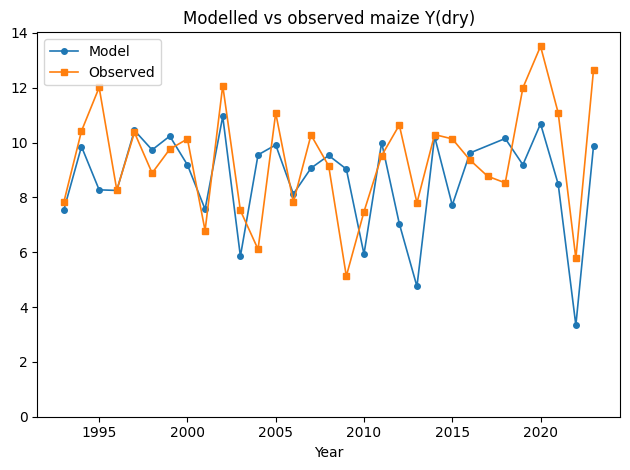

In [22]:
seasonal_grain_mkge_opt = rerun_best(es_grain_mkge.result.xbest, "grain_mkge_opt")
print("=== Best solution optimised for grain mkge ===")
plot_yield_timeseries_comparison(seasonal_grain_mkge_opt, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

In [ ]:
seasonal_combined_opt = rerun_best(es_combined.result.xbest, "combined_opt")
print("=== Best solution optimised for combined nRMSE ===")
plot_yield_timeseries_comparison(seasonal_combined_opt, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass")

In [ ]:
plot_yield_timeseries_comparison(seasonal_combined_opt, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")